TRABAJO PRACTICO N° 2 MI PRIMER RED NEURONAL

El punto de partida es definir la arquitectura de la red, o sea cuantas capas, cuantas neuronas por capas y como es su conectividad.

**El objetivo** de nuestra red será replicar la siguiente función
Esta función es unidimensional por lo que tenemos una solo imput => “x” y un solo output. 

**Condiciones la arquitectura** son 3 capas, una neurona de entrada (que toma 1 solo input, lo procesa y envia el output a todas las enuronas de la capa media), una capa media de 2 o más neuronas, y una capa de salida que condensa las salidas de la capa media y emite la predicciòn.


In [15]:
import numpy as np

def initialize_specific_network():
    # Definición de la arquitectura solicitada [cite: 54, 55]
    input_size = 1
    hidden_sizes = [2, 3]
    output_size = 1
    
    # Lista de tamaños de capa: [1, 2, 3, 1] 
    layer_sizes = [input_size] + hidden_sizes + [output_size]
    print(f"Dimensiones de las capas: {layer_sizes}")
    
    network = []
    for i in range(len(layer_sizes) - 1):
        # Los pesos se inicializan al azar y se achican (* 0.1) 
        # La forma es (neuronas_siguiente, neuronas_actual) 
        weights = np.random.randn(layer_sizes[i + 1], layer_sizes[i]) * 0.1
        
        # Los bias se inicializan en cero 
        biases = np.zeros(layer_sizes[i + 1])
        
        network.append((weights, biases))
        
    return network

# Ejecución y verificación de dimensiones 
mi_red = initialize_specific_network()

for i, (w, b) in enumerate(mi_red):
    print(f"\n--- Capa {i+1} ---")
    print(f"Pesos (Weights) shape: {w.shape} -> {w.size} valores")
    print(f"Sesgos (Biases) shape: {b.shape} -> {b.size} valores")
    print(f"Valores de W:\n{w}")

Dimensiones de las capas: [1, 2, 3, 1]

--- Capa 1 ---
Pesos (Weights) shape: (2, 1) -> 2 valores
Sesgos (Biases) shape: (2,) -> 2 valores
Valores de W:
[[ 0.1367476 ]
 [-0.16857485]]

--- Capa 2 ---
Pesos (Weights) shape: (3, 2) -> 6 valores
Sesgos (Biases) shape: (3,) -> 3 valores
Valores de W:
[[ 0.07019101  0.01089028]
 [-0.00487284 -0.03907092]
 [-0.07097895 -0.05214508]]

--- Capa 3 ---
Pesos (Weights) shape: (1, 3) -> 3 valores
Sesgos (Biases) shape: (1,) -> 1 valores
Valores de W:
[[-0.10297261 -0.11956735  0.03139774]]


Genera una red con 1 entrada, 2 neuronas en la primer capa, 3 neuronasen la segunda capa y 1 valor de salda.
Graficar la red

Arquitectura 1-2-3-1, la estructura fluye de izquierda a derecha:

Entrada (x): Un solo círculo que recibe el dato.

Capa Oculta 1 (L1): 2 neuronas. Cada una recibe una conexión desde la entrada (2 pesos en total).

Capa Oculta 2 (L2): 3 neuronas. Cada una de estas 3 neuronas recibe conexiones de las 2 neuronas anteriores. Esto genera una red "fully connected" de 3 x 2 = 6  flechas (pesos).

Salida (y): 1 neurona que condensa la información de las 3 neuronas de la L2 (3 pesos).

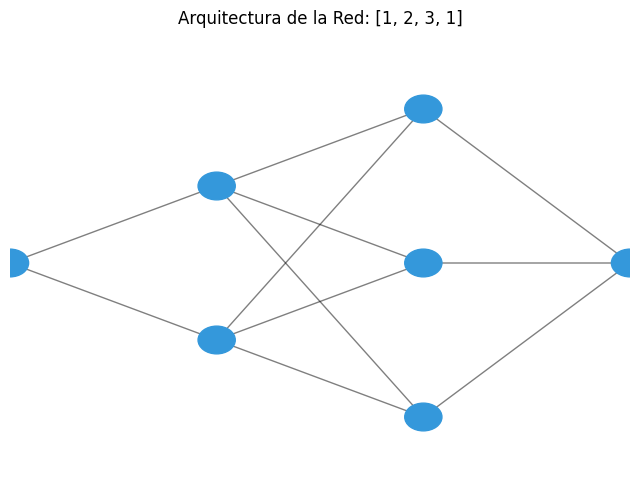

In [21]:
###GRAFICOS ARQUITECTURA DE LA RED 1-2-3-1
import matplotlib.pyplot as plt

def dibujar_red(arquitectura):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.axis('off')
    
    # Coordenadas de las neuronas
    n_capas = len(arquitectura)
    v_spacing = 1.0 / max(arquitectura)
    h_spacing = 1.0 / (n_capas - 1)
    
    posiciones = []
    
    # Dibujar neuronas (nodos)
    for i, n_neuronas in enumerate(arquitectura):
        capa_pos = []
        x = i * h_spacing
        for j in range(n_neuronas):
            # Centrar verticalmente las neuronas de cada capa
            y = 0.5 + (j - (n_neuronas - 1) / 2) * v_spacing
            ax.add_artist(plt.Circle((x, y), 0.03, color='#3498db', zorder=6))
            capa_pos.append((x, y))
        posiciones.append(capa_pos)
        
    # Dibujar conexiones (pesos/weights)
    for i in range(len(posiciones) - 1):
        for p1 in posiciones[i]:
            for p2 in posiciones[i+1]:
                ax.annotate("", xy=p2, xytext=p1, 
                            arrowprops=dict(arrowstyle="->", color="black", alpha=0.5))

    plt.title(f"Arquitectura de la Red: {arquitectura}")
    plt.show()

# Definimos la red del ejercicio: 1 entrada, capas ocultas de 2 y 3, 1 salida
arquitectura_solicitada = [1, 2, 3, 1] 
dibujar_red(arquitectura_solicitada)

In [18]:
### RESULTADOS
def initialize_network(input_size, hidden_sizes, output_size):
    # Definimos la lista de tamaños: [1, 2, 3, 1] 
    layer_sizes = [input_size] + hidden_sizes + [output_size]
    print('Configuración de capas:', layer_sizes) 
    
    network = []
    for i in range(len(layer_sizes) - 1):
        # Pesos: (neuronas siguiente capa, neuronas capa actual) 
        # Se multiplican por 0.1 para que sean valores pequeños 
        weights = np.random.randn(layer_sizes[i + 1], layer_sizes[i]) * 0.1
        
        # Biases: Uno por cada neurona de la capa siguiente, en cero 
        biases = np.zeros(layer_sizes[i + 1])
        
        network.append((weights, biases)) 
    return network

# Parámetros solicitados
input_size = 1
hidden_sizes = [2, 3] # Dos capas medias 
output_size = 1

# Inicializamos la red
mi_red = initialize_network(input_size, hidden_sizes, output_size)

# Verificación de formas (Shape Check) 
for i, (w, b) in enumerate(mi_red):
    print(f"\nConexión Capa {i} -> Capa {i+1}:")
    print(f"  Matriz de Pesos (W): {w.shape} (Filas: L+1, Columnas: L)") 
    print(f"  Vector de Biases (b): {b.shape}") 

Configuración de capas: [1, 2, 3, 1]

Conexión Capa 0 -> Capa 1:
  Matriz de Pesos (W): (2, 1) (Filas: L+1, Columnas: L)
  Vector de Biases (b): (2,)

Conexión Capa 1 -> Capa 2:
  Matriz de Pesos (W): (3, 2) (Filas: L+1, Columnas: L)
  Vector de Biases (b): (3,)

Conexión Capa 2 -> Capa 3:
  Matriz de Pesos (W): (1, 3) (Filas: L+1, Columnas: L)
  Vector de Biases (b): (1,)


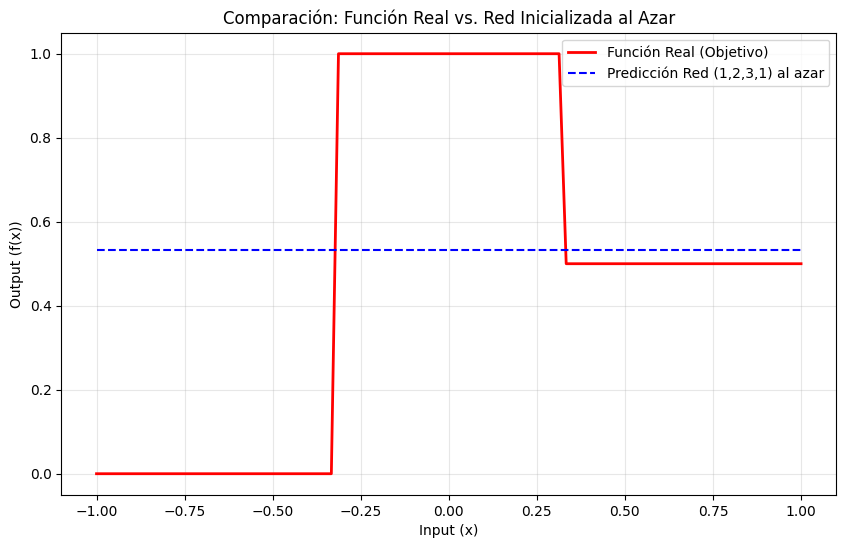

In [ ]:
###GGRAFICA DE LA FUNCION REAL VS. PREDICCIÓN DE LA RED INICIALIZADA AL AZAR
import numpy as np
import matplotlib.pyplot as plt

# 1. Funciones base del TP
def sigmoid(x):
    return 1 / (1 + np.exp(-x)) 

def forward_network_batch(inputs, network):
    activations = [inputs] 
    for weights, biases in network:
        # Cálculo: z = xW^T + b 
        z = np.dot(inputs, weights.T) + biases
        inputs = sigmoid(z) 
        activations.append(inputs)
    return activations 

# 2. Inicialización de la arquitectura (1, 2, 3, 1) 
def initialize_network(input_size, hidden_sizes, output_size):
    layer_sizes = [input_size] + hidden_sizes + [output_size] 
    network = []
    for i in range(len(layer_sizes) - 1):
        # Pesos al azar * 0.1 y biases en cero 
        weights = np.random.randn(layer_sizes[i + 1], layer_sizes[i]) * 0.1
        biases = np.zeros(layer_sizes[i + 1])
        network.append((weights, biases))
    return network

# 3. Preparación de datos (Ejercicio 1.2.1) 
x_batch = np.linspace(-1, 1, 100).reshape(-1, 1)

# Función real definida en el TP 
y_true = np.where(x_batch < -0.33, 0, 
                 np.where(x_batch < 0.33, 1, 0.5))

# Crear la red solicitada
mi_red = initialize_network(input_size=1, hidden_sizes=[2, 3], output_size=1)

# Realizar la predicción (Forward Pass)
activaciones = forward_network_batch(x_batch, mi_red)
y_predicha = activaciones[-1] # Tomamos la salida de la última capa 
# 4. Graficar
plt.figure(figsize=(10, 6))
plt.plot(x_batch, y_true, label='Función Real (Objetivo)', color='red', linewidth=2)
plt.plot(x_batch, y_predicha, label='Predicción Red (1,2,3,1) al azar', color='blue', linestyle='--')
plt.title("Comparación: Función Real vs. Red Inicializada al Azar")
plt.xlabel("Input (x)")
plt.ylabel("Output (f(x))")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Ejercicio 1.2.1) 

Escriba un codigo que dados los valores de entrada de la función (puede usar el intervalo -1 a 1, espaciado en 0.1), lo que serìa un batch, realice el fwd_pass para una dada red inicializada al azar y grafique el resultado. Grafique ademas la función correcta. 

Pruebe diferentes arquitecturas. ¿cree que es posible solo por azar obtener una red que recupere la función? 

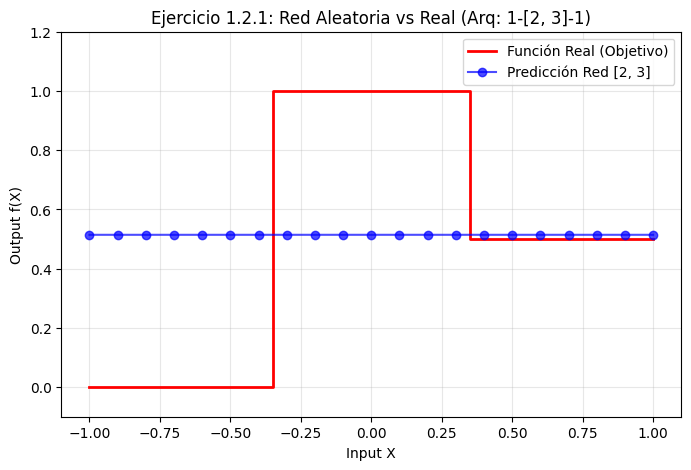

In [ ]:
#import numpy as np
#import matplotlib.pyplot as plt

# --- 1. Definición de Funciones Base ---

def sigmoid(x):
    """Función de activación sigmoidea [cite: 77, 78]"""
    return 1 / (1 + np.exp(-x))

def initialize_network(input_size, hidden_sizes, output_size):
    """Inicializa la red con pesos pequeños y biases en cero [cite: 34, 58]"""
    layer_sizes = [input_size] + hidden_sizes + [output_size]
    network = []
    for i in range(len(layer_sizes) - 1):
        # Pesos: (neuronas sig capa x neuronas capa actual) [cite: 44, 59]
        weights = np.random.randn(layer_sizes[i + 1], layer_sizes[i]) * 0.1
        biases = np.zeros(layer_sizes[i + 1]) # [cite: 47]
        network.append((weights, biases))
    return network

def forward_network_batch(inputs, network):
    """Realiza el forward pass por toda la red [cite: 86, 92]"""
    activations = [inputs]
    for weights, biases in network:
        # Suma ponderada y activación [cite: 85, 93]
        z = np.dot(inputs, weights.T) + biases
        inputs = sigmoid(z)
        activations.append(inputs)
    return activations

# --- 2. Preparación de los Datos (El "Batch") ---

# Intervalo -1 a 1, espaciado en 0.1 [cite: 107]
x_batch = np.arange(-1, 1.1, 0.1).reshape(-1, 1)

# Función correcta (Objetivo) según los rangos del TP[cite: 27, 28]:
# f(x)=0 (-1 a -0.33), f(x)=1 (-0.33 a 0.33), f(x)=0.5 (0.33 a 1.01)
y_true = np.where(x_batch < -0.33, 0, 
                 np.where(x_batch < 0.33, 1, 0.5))

# --- 3. Ejecución y Graficación ---

def graficar_ejercicio(arquitectura):
    # Inicializar red al azar
    red = initialize_network(input_size=1, hidden_sizes=arquitectura, output_size=1)
    
    # Forward pass
    activaciones = forward_network_batch(x_batch, red)
    y_pred = activaciones[-1] # La última activación es la predicción final [cite: 101]
    
    # Graficar
    plt.figure(figsize=(8, 5))
    plt.step(x_batch, y_true, where='mid', label='Función Real (Objetivo)', color='red', linewidth=2)
    plt.plot(x_batch, y_pred, 'o-', label=f'Predicción Red {arquitectura}', color='blue', alpha=0.7)
    
    plt.title(f"Ejercicio 1.2.1: Red Aleatoria vs Real (Arq: 1-{arquitectura}-1)")
    plt.xlabel("Input X")
    plt.ylabel("Output f(X)")
    plt.ylim(-0.1, 1.2)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Probar con la arquitectura solicitada (2 neuronas en capa 1, 3 en capa 2) [cite: 56]
graficar_ejercicio([2, 3])

# Probar con una arquitectura más compleja para ver si cambia algo por azar
# graficar_ejercicio([10, 10, 10])

Ejercicio 1.2.2) 

Escriba un codigo que tomando los valores de entrada de la función (use el intervalo -1 a 1, espaciado en 0.1), realicé el entrenamiento y permita analizar (graficar) como decae la LF , y luego como es la predicciòn de la red entrenada comparada con la real.

Analice el efecto de la cantidad de pasos y el LR (consejo, pruebe utilizar un LR que decaiga a medida que avanza el entrenamiento). 

Analice el efecto de cambiar la arquitectura de las capas ocultas de la red (recuerde que necesita 1 input y 1 neurona de salida). 

Nota: recuerde que los ipnuts y valores y_true deben tener formato np.array (es muy fàcil convertir una lista a este
formato)

In [27]:
### function using NumPy and Matplotlib.
import numpy as np
import matplotlib.pyplot as plt

In [28]:
# --- 1. ACTIVACIÓN Y DERIVADA ---
def sigmoid(x):
    """Función de activación sigmoidea [cite: 77, 78]"""
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    """Derivada de la sigmoidea para el backprop [cite: 134, 136]"""
    s = sigmoid(x)
    return s * (1 - s)


In [29]:
# --- 2. FUNCIÓN DE PÉRDIDA ---
def rmse_loss(y_pred, y_true):
    """Raíz del Error Cuadrático Medio (RMSE) para regresión """
    return np.sqrt(np.mean((y_pred - y_true)**2))

# --- 3. INICIALIZACIÓN ---
def initialize_network(input_size, hidden_sizes, output_size):
    """Inicializa pesos (azar * 0.1) y biases (cero) para cada capa """
    layer_sizes = [input_size] + hidden_sizes + [output_size]
    network = []
    for i in range(len(layer_sizes) - 1):
        # Matriz: neuronas siguiente capa x neuronas capa actual 
        weights = np.random.randn(layer_sizes[i + 1], layer_sizes[i]) * 0.1
        biases = np.zeros(layer_sizes[i + 1])
        network.append((weights, biases))
    return network

In [31]:
# --- 4. FORWARD PASS ---
def forward_network_batch(inputs, network):
    """Calcula las activaciones capa por capa """
    activations = [inputs]
    for weights, biases in network:
        # z = xW^T + b matriz de pesos transpuesta para multiplicar con input 
        z = np.dot(inputs, weights.T) + biases
        inputs = sigmoid(z)
        activations.append(inputs)
    return activations

# --- 5. BACKWARD PASS Y ACTUALIZACIÓN ---
def backward_network_batch(activations, network, y_true, learning_rate):
    """Propaga el error y actualiza parámetros """
    y_pred = activations[-1]
    loss = rmse_loss(y_pred, y_true)
    
    # Gradiente de la pérdida respecto a la salida [cite: 164]
    # (Pequeño ajuste para evitar división por cero)
    d_loss = (y_pred - y_true) / (len(y_true) * loss + 1e-15)
    
    for i in reversed(range(len(network))):
        weights, biases = network[i]
        inputs = activations[i]
        
        # Derivada de la activación de la capa actual 
        # Se calcula sobre el valor z, que aquí recuperamos mediante la activación
        activation_derivative = activations[i + 1] * (1 - activations[i + 1])
        
        # Gradientes de la capa 
        d_activation = d_loss * activation_derivative
        d_weights = np.dot(d_activation.T, inputs) / len(inputs)
        d_biases = np.mean(d_activation, axis=0)
        d_loss = np.dot(d_activation, weights) # Gradiente para la capa anterior
        
        # Actualización de pesos y biases (SGD) 
        new_weights = weights - learning_rate * d_weights
        new_biases = biases - learning_rate * d_biases
        network[i] = (new_weights, new_biases)
        
    return loss

In [32]:
# --- 6. DATOS Y ENTRENAMIENTO (Ejercicio 1.2.2) 
x_vals = np.linspace(-1, 1, 100).reshape(-1, 1)
y_true = np.where(x_vals < -0.33, 0, 
                 np.where(x_vals < 0.33, 1, 0.5))

# Inicializamos una red (ejemplo: 1 entrada, 10 ocultas, 1 salida) 
mi_red = initialize_network(input_size=1, hidden_sizes=[10, 10], output_size=1)


epochs = 5000
lr = 0.5
losses = []

for epoch in range(epochs):
    # Forward 
    activations = forward_network_batch(x_vals, mi_red)
    # Backward y Update 
    current_loss = backward_network_batch(activations, mi_red, y_true, lr)
    losses.append(current_loss)
    
    # LR Decay opcional 
    if epoch % 1000 == 0:
        lr *= 0.9

In [33]:
###ARQUITECTURA DE 3 CAPAS
x_vals = np.linspace(-1, 1, 100).reshape(-1, 1)
y_true = np.where(x_vals < -0.33, 0, 
                 np.where(x_vals < 0.33, 1, 0.5))

# Inicializamos una red (ejemplo: 1 entrada, 10 ocultas, 1 salida) 
mi_red = initialize_network(input_size=1, hidden_sizes=[3, 3], output_size=1)


epochs = 5000
lr = 0.5
losses = []

for epoch in range(epochs):
    # Forward 
    activations = forward_network_batch(x_vals, mi_red)
    # Backward y Update 
    current_loss = backward_network_batch(activations, mi_red, y_true, lr)
    losses.append(current_loss)
    
    # LR Decay opcional 
    if epoch % 1000 == 0:
        lr *= 0.9

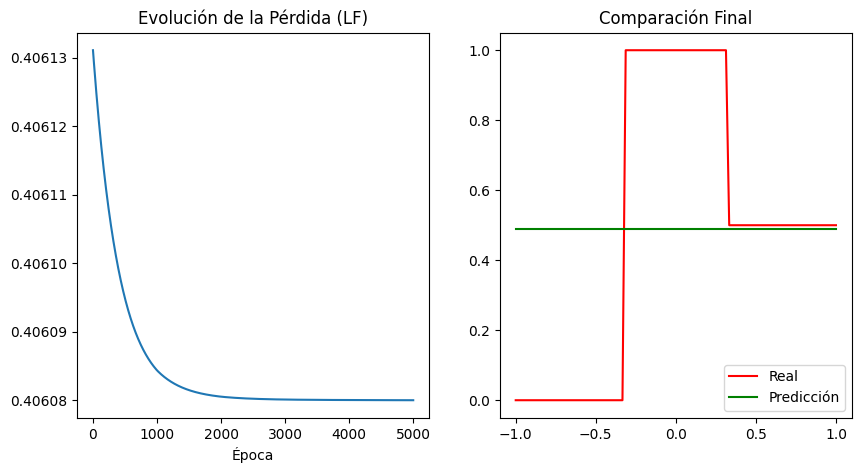

In [34]:
# --- 7. VISUALIZACIÓN ---
y_final = forward_network_batch(x_vals, mi_red)[-1]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Evolución de la Pérdida (LF)")
plt.xlabel("Época")

plt.subplot(1, 2, 2)
plt.plot(x_vals, y_true, label="Real", color="red")
plt.plot(x_vals, y_final, label="Predicción", color="green")
plt.title("Comparación Final")
plt.legend()
plt.show()